![fdv](kolmogorov.png)


1. Пусть Xi ∼ N (0, 1).
1) Построить эмпирическую функцию распределения (ЭФР) на одном графике с теоретической
функцией распределения при разных n (проиллюстрировать сходимость ЭФР к ф.р.). То же для
Xi ∼ R[0, 1], Xi ∼ Bin(m, p), где m = 3, m = 10.

2) Построить 95% доверительную полосу для ф.р., используя а) критерий Колмогорова. б) нера-
венство Дворецкого-Кифера-Вольфовица.

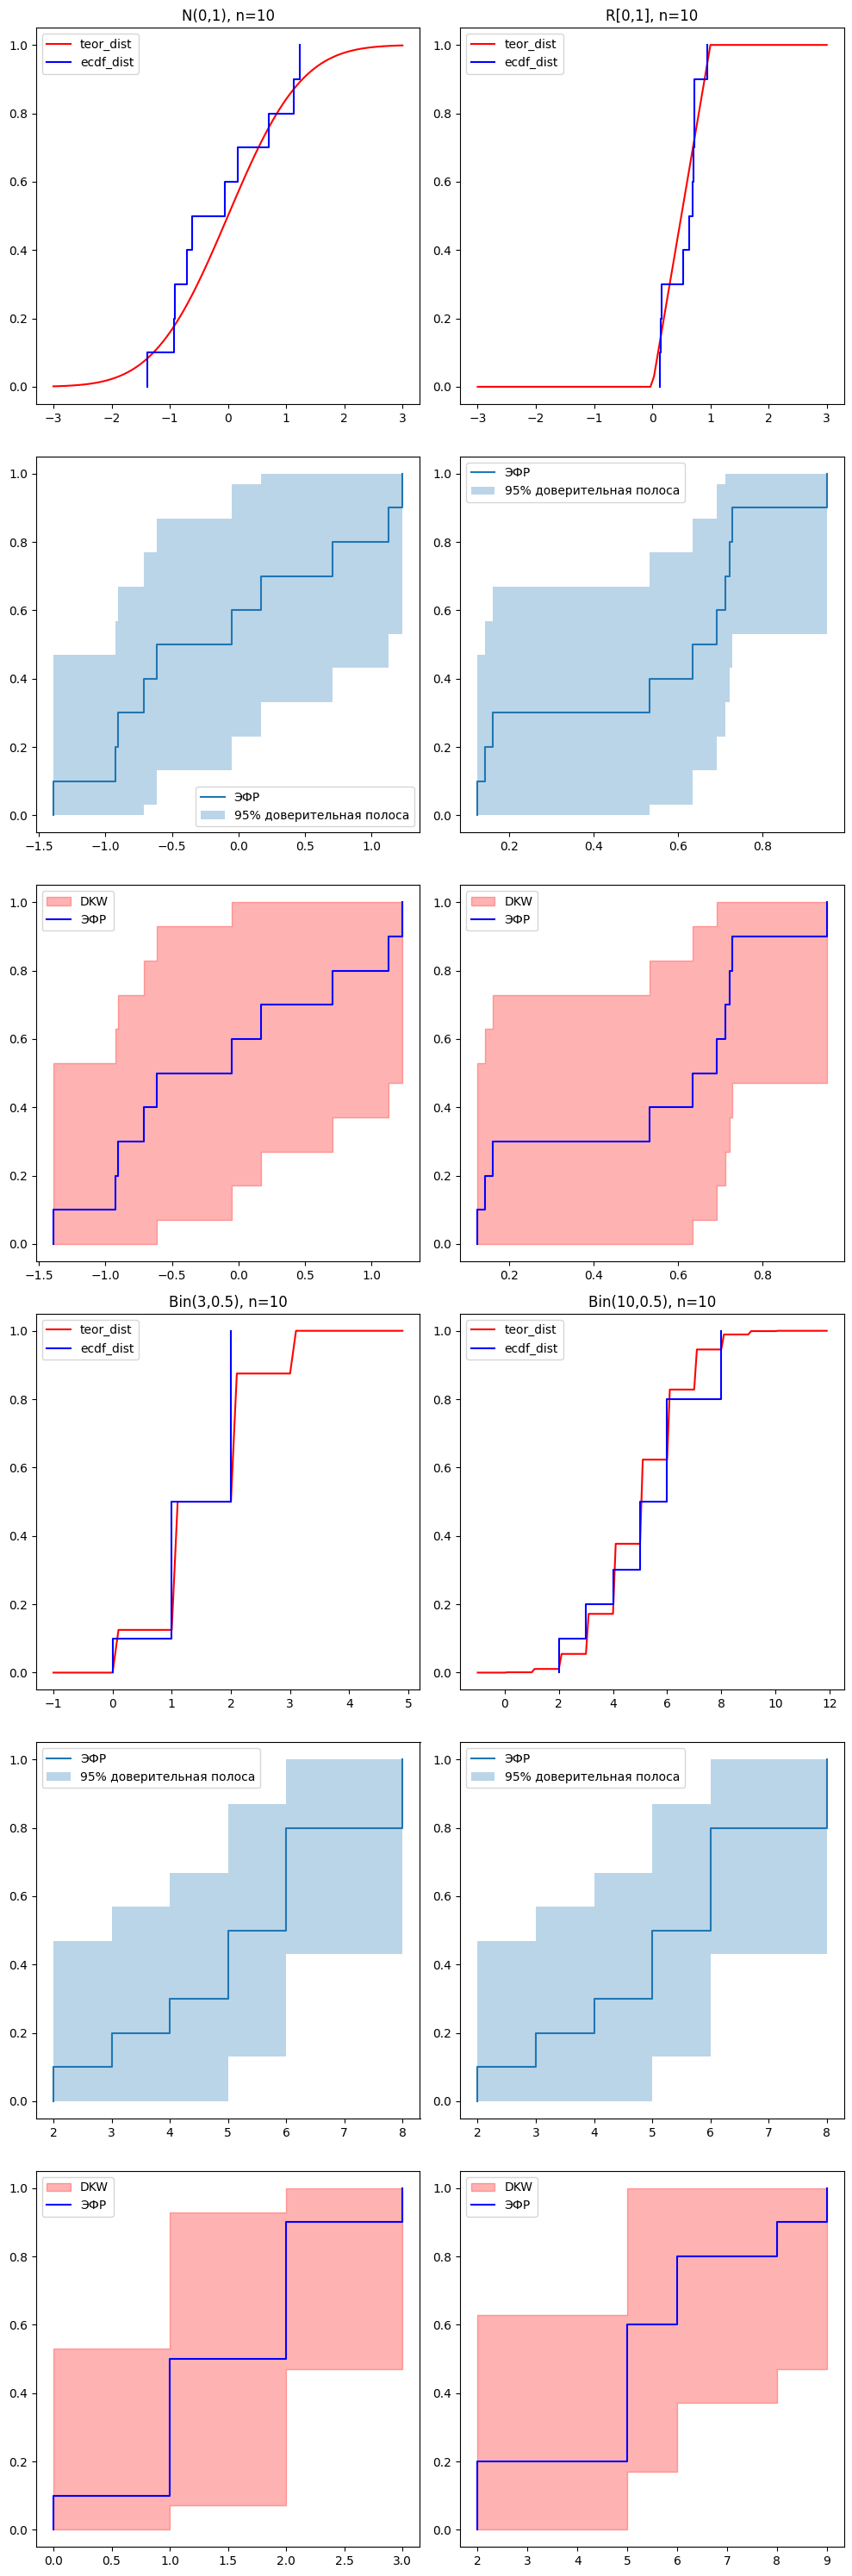

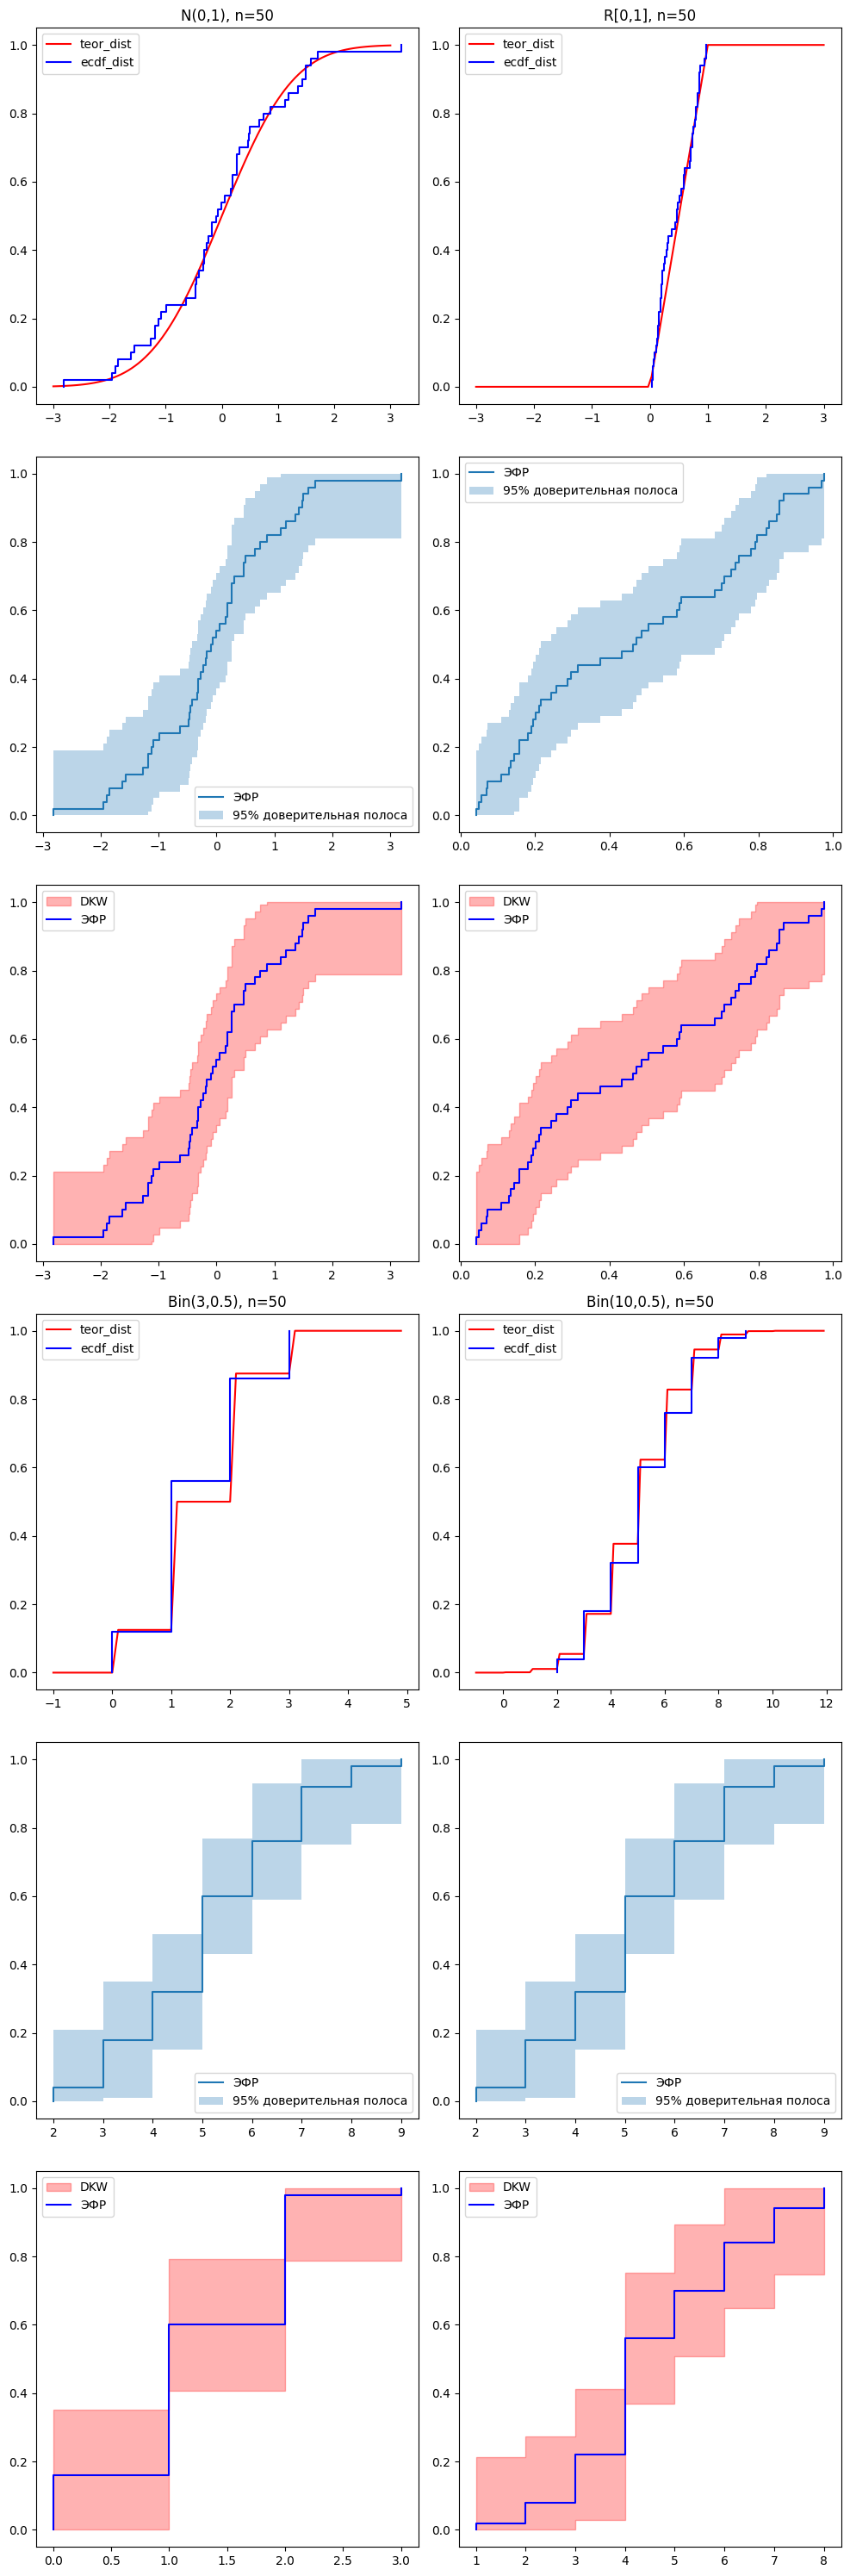

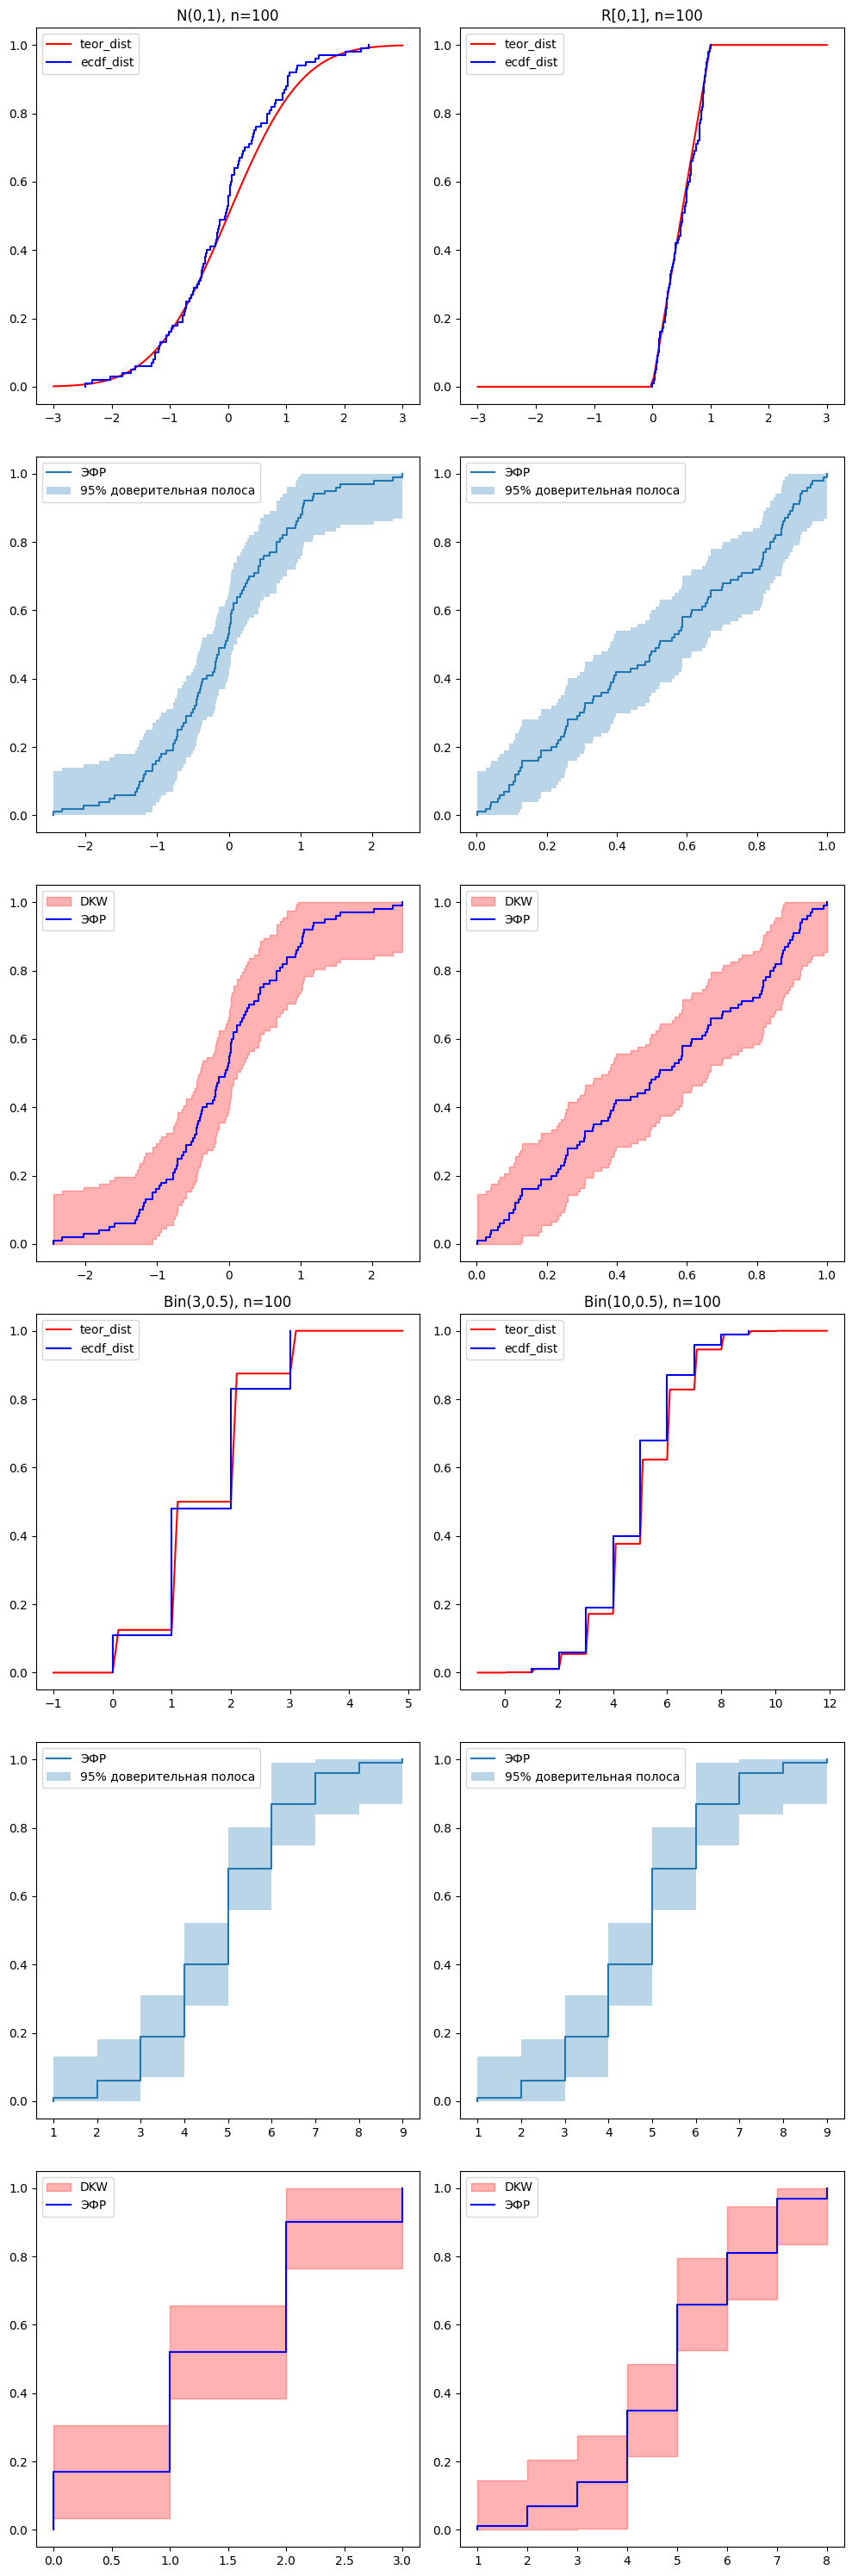

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.distributions.empirical_distribution import ECDF


def bild_empirical_distribution_func(n_values, p, m_values):
    x = np.linspace(-3, 3, 100)
    for n in n_values:
        plt.figure(figsize=(10, 24))
        sample_norm = np.random.normal(0, 1, n)
        theor_dist_norm = stats.norm.cdf(x, 0, 1)
        ecdf_norm = ECDF(sample_norm)
        plt.subplot(6, 2, 1)
        plt.plot(x, theor_dist_norm, color = 'red', label = 'teor_dist')
        plt.step(ecdf_norm.x, ecdf_norm.y, where='post', color = 'blue', label = 'ecdf_dist')
        plt.title(f'N(0,1), n={n}')
        plt.legend()
        sample_un = np.random.uniform(0, 1, n)
        theor_dist_un = stats.uniform.cdf(x, 0, 1)
        ecdf_un = ECDF(sample_un)
        plt.subplot(6, 2, 2)
        plt.plot(x, theor_dist_un, color = 'red', label = 'teor_dist')
        plt.step(ecdf_un.x, ecdf_un.y, where='post', color = 'blue', label = 'ecdf_dist')    
        plt.title(f'R[0,1], n={n}') 
        plt.legend()  
        
        plt.subplot(6, 2, 3)
        bild_confidence_zone_with_kolmogorov(alpha, sample_norm, n, ecdf_norm)
        
        plt.subplot(6, 2, 4)
        bild_confidence_zone_with_kolmogorov(alpha, sample_un, n, ecdf_un)
        
        plt.subplot(6, 2, 5)
        bild_confidence_zone_with_DKW_inequality(alpha, n, ecdf_norm)
        
        plt.subplot(6, 2, 6)
        bild_confidence_zone_with_DKW_inequality(alpha, n, ecdf_un)
        for i, m in enumerate(m_values):
            plt.subplot(6, 2, i+7)
            x_bin = np.arange(-1, m+2, 0.1)
            def bild_for_binom(m, p):
                sample_bin = np.random.binomial(m, p, n)
                theor_dist_bin = stats.binom.cdf(x_bin, m, p)
                return sample_bin, theor_dist_bin
            sample_bin, theor_dist_bin = bild_for_binom(m, p)
            ecdf_bin = ECDF(sample_bin)
            plt.plot(x_bin, theor_dist_bin, color = 'red', label = 'teor_dist')
            plt.step(ecdf_bin.x, ecdf_bin.y, where='post', color = 'blue', label = 'ecdf_dist')
            plt.title(f'Bin({m},{p}), n={n}')
            plt.legend()
                
        for i, m in enumerate(m_values):
            plt.subplot(6, 2, 9+i)
            sample_bin, _ = bild_for_binom(m, p)
            bild_confidence_zone_with_kolmogorov(alpha, sample_bin, n, ecdf_bin)
        
        for i, m in enumerate(m_values):
            plt.subplot(6, 2, 11+i)
            sample_bin, _ = bild_for_binom(m, p)
            ecdf_bin = ECDF(sample_bin)
            bild_confidence_zone_with_DKW_inequality(alpha, n, ecdf_bin)
        
        plt.tight_layout()
        plt.show()

#Теперь построим 95% доверительную полосу для ф.р., используя а) критерий Колмогорова
def bild_confidence_zone_with_kolmogorov(alpha, sample, n, ecdf):            #ISF = Inverse Survival Function 
    x_unique = ecdf.x  # это отсортированные уникальные значения
    y_ecdf = ecdf.y    # это значения ЭФР (уже правильно посчитанные)
    d_alpha = stats.ksone.isf(alpha, n) #d, такое что P(D_n > d) = alpha, D_n - статистика Колмогорова, т.е. sup|F_n - F| по x
    lower = np.maximum(0, y_ecdf - d_alpha)
    upper = np.minimum(1, y_ecdf + d_alpha)
    plt.step(x_unique, y_ecdf, where='post', label='ЭФР')
    plt.fill_between(x_unique, lower, upper, step='post', alpha=0.3, label='95% доверительная полоса')
    plt.legend()

def bild_confidence_zone_with_DKW_inequality(alpha, n, ecdf):
    x_unique = ecdf.x  
    y_ecdf = ecdf.y    
    epsilon = np.sqrt(-np.log(alpha/2) / (2 * n))
    lower = np.maximum(0, y_ecdf - epsilon)
    upper = np.minimum(1, y_ecdf + epsilon)
    plt.fill_between(x_unique, lower, upper, step='post', alpha=0.3, color = 'red', label=f'DKW')
    plt.step(x_unique, y_ecdf, where='post', color='blue', label='ЭФР')
    plt.legend()


n_values = [10, 50, 100]
m_values = np.array([3, 10])  
p = 0.5
alpha = 0.05
bild_empirical_distribution_func(n_values, p, m_values)    